In [4]:
import sys
sys.path.append("../src")

import numpy as np
import torch

waveforms = np.load("../data/raw/waveforms.npy")
valid_spike_times = np.load("../data/raw/valid_spike_times.npy")
print(f"Waveforms shape: {waveforms.shape}")

n_spikes = waveforms.shape[0]
flattened = waveforms.reshape(n_spikes, -1)
print(f"Flattened shape: {flattened.shape}")

mean = flattened.mean()
std = flattened.std()
normalized = (flattened - mean) / std

data_tensor = torch.tensor(normalized, dtype=torch.float32)

Waveforms shape: (2685, 120, 40)
Flattened shape: (2685, 4800)


latent_dim=2: final reconstruction loss=0.5373
latent_dim=8: final reconstruction loss=0.3699
latent_dim=16: final reconstruction loss=0.2910
latent_dim=32: final reconstruction loss=0.2172


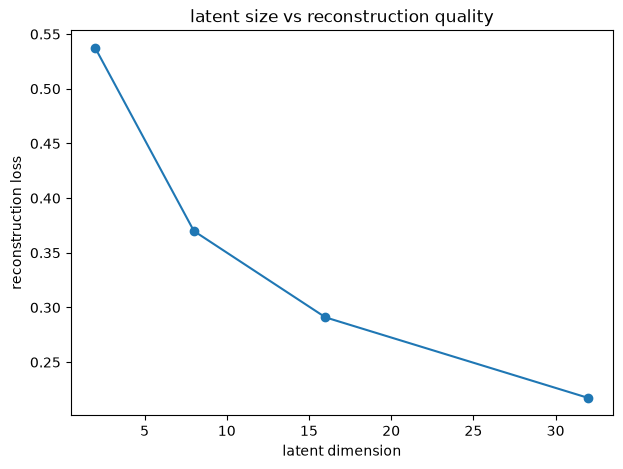

In [6]:
from autoencoder import WaveformAutoencoder, train_autoencoder
import matplotlib.pyplot as plt

input_dim = flattened.shape[1]
latent_dims_to_try = [2, 8, 16, 32]
final_losses = []

for dim in latent_dims_to_try:
    torch.manual_seed(0)
    model = WaveformAutoencoder(input_dim, dim)
    losses = train_autoencoder(model, data_tensor, epochs=30)
    final_losses.append(losses[-1])
    print(f"latent_dim={dim}: final reconstruction loss={losses[-1]:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(latent_dims_to_try, final_losses, marker='o')
plt.xlabel("latent dimension")
plt.ylabel("reconstruction loss")
plt.title("latent size vs reconstruction quality")
plt.savefig("../figures/latent_size.png")
plt.show()

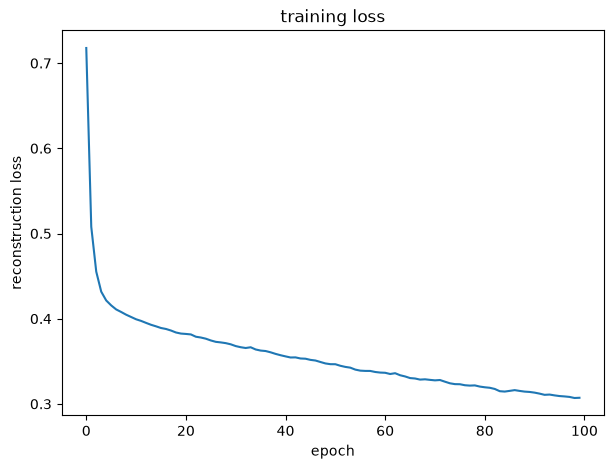

In [7]:
torch.manual_seed(0)
final_model = WaveformAutoencoder(input_dim, latent_dim=8)
final_losses = train_autoencoder(final_model, data_tensor, epochs=100)

plt.figure(figsize=(7, 5))
plt.plot(final_losses)
plt.xlabel("epoch")
plt.ylabel("reconstruction loss")
plt.title("training loss")
plt.savefig("../figures/training_loss.png")
plt.show()

In [8]:
final_model.eval()
with torch.no_grad():
    _, features = final_model(data_tensor)
features = features.numpy()

print(f"Features shape: {features.shape}")

np.save("../data/raw/autoencoder_features.npy", features)
print("saved autoencoder features")

Features shape: (2685, 8)
saved autoencoder features


In [9]:
from sklearn.cluster import KMeans

n_clusters = 10  # starting guess; we'll revisit this
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features)

print(f"Cluster sizes: {np.bincount(cluster_labels)}")

Cluster sizes: [ 89 290 112 693 345 140  23 238 372 383]


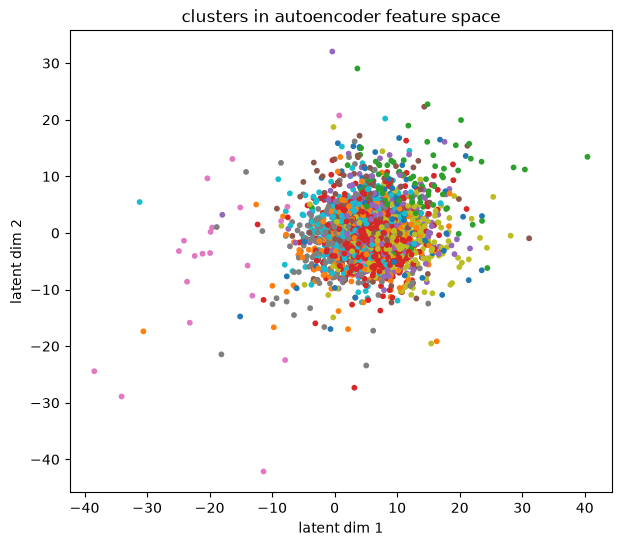

In [10]:
# Visualize clusters using the first 2 latent dimensions
plt.figure(figsize=(7, 6))
scatter = plt.scatter(features[:, 0], features[:, 1], c=cluster_labels, cmap='tab10', s=10)
plt.xlabel("latent dim 1")
plt.ylabel("latent dim 2")
plt.title("clusters in autoencoder feature space")
plt.savefig("../figures/clusters.png")
plt.show()

In [12]:
fs = 30000
ground_truth_spikes = np.load("../data/raw/c37_extracellular_spikes.npy")

tolerance_samples = int(0.001 * fs)

is_ground_truth = np.zeros(len(valid_spike_times), dtype=bool)
for i, t in enumerate(valid_spike_times):
    if np.any(np.abs(ground_truth_spikes - t) <= tolerance_samples):
        is_ground_truth[i] = True

print(f"Of {len(valid_spike_times)} spikes, {is_ground_truth.sum()} are ground truth")

gt_clusters = cluster_labels

Of 2685 spikes, 363 are ground truth


In [17]:
tolerance_samples = int(0.001 * fs)

# For each valid detected spike, check if it matches a ground truth spike
is_ground_truth = np.zeros(len(valid_spike_times), dtype=bool)
for i, t in enumerate(valid_spike_times):
    if np.any(np.abs(ground_truth_spikes - t) <= tolerance_samples):
        is_ground_truth[i] = True

print(f"Of {len(valid_spike_times)} spikes, {is_ground_truth.sum()} are ground truth")

# Which cluster do the ground truth spikes mostly fall into?
gt_clusters = cluster_labels[is_ground_truth]
print(f"Ground truth spikes' clustes: {np.bincount(gt_clusters, minlength=n_clusters)}")

Of 2685 spikes, 363 are ground truth
Ground truth spikes' clustes: [  7  12  53  10  10  12   3   8 240   8]


In [18]:
cluster_8_total = np.sum(cluster_labels == 8)
cluster_8_ground_truth = np.sum((cluster_labels == 8) & is_ground_truth)

purity = cluster_8_ground_truth / cluster_8_total * 100
print(f"Cluster 8: {cluster_8_total} total spikes, {cluster_8_ground_truth} are ground truth ({purity:.1f}% purity)")

Cluster 8: 372 total spikes, 240 are ground truth (64.5% purity)


In [19]:
np.save("../data/raw/cluster_labels.npy", cluster_labels)
print("saved cluster labels")

saved cluster labels


In [20]:
from sklearn.decomposition import PCA

# Same input as the autoencoder: flattened, normalized waveforms
pca = PCA(n_components=8)  # same dimensionality as your autoencoder for a fair comparison
pca_features = pca.fit_transform(normalized)

print(f"PCA features shape: {pca_features.shape}")
print(f"Variance explained by 8 components: {pca.explained_variance_ratio_.sum():.3f}")

PCA features shape: (2685, 8)
Variance explained by 8 components: 0.465


In [21]:
from sklearn.cluster import KMeans

kmeans_pca = KMeans(n_clusters=10, random_state=42, n_init=10)
pca_cluster_labels = kmeans_pca.fit_predict(pca_features)

print(f"Cluster sizes: {np.bincount(pca_cluster_labels)}")

Cluster sizes: [374 362 262 243 308 308 242 321 230  35]


In [22]:
fs = 30000
ground_truth_spikes = np.load("../data/raw/c37_extracellular_spikes.npy")
tolerance_samples = int(0.001 * fs)

is_ground_truth = np.zeros(len(valid_spike_times), dtype=bool)
for i, t in enumerate(valid_spike_times):
    if np.any(np.abs(ground_truth_spikes - t) <= tolerance_samples):
        is_ground_truth[i] = True

gt_clusters_pca = pca_cluster_labels[is_ground_truth]
best_cluster_pca = np.argmax(np.bincount(gt_clusters_pca, minlength=10))

cluster_total = np.sum(pca_cluster_labels == best_cluster_pca)
cluster_gt = np.sum((pca_cluster_labels == best_cluster_pca) & is_ground_truth)
purity_pca = cluster_gt / cluster_total * 100

print(f"PCA best cluster ({best_cluster_pca}): {cluster_total} total, {cluster_gt} ground truth ({purity_pca:.1f}% purity)")

PCA best cluster (5): 308 total, 166 ground truth (53.9% purity)


In [23]:
np.save("../data/raw/pca_features.npy", pca_features)
print("saved pca features")

saved pca features
